# Advanced Cosmological Model Analysis

This notebook demonstrates the newest features of the cosmology framework:
1. **Comparison Tables**: Consolidating results from multiple models into a single Markdown table.
2. **Specialized Parameter Visualization**: Plotting 1D histograms of "extension" parameters (e.g., $w, \epsilon, \alpha$) that distinguish models from $\Lambda$CDM.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown
from src.run_inference import load_mcmc_results, generate_comparison_table
from src.plotting import plot_extensions_1d, compare_models_corner

## 1. Load Pre-computed results

We assume that `results_lcdm.npz`, `results_wcdm.npz`, and `results_bd.npz` were generated in previous steps.

In [2]:
try:
    res_lcdm = load_mcmc_results("results_lcdm.npz")
    res_wcdm = load_mcmc_results("results_wcdm.npz")
    res_bd = load_mcmc_results("results_bd.npz")
    print("Successfully loaded results!")
except FileNotFoundError:
    print("Results files not found. Please run MCMC in demo_comparison.ipynb first.")

Successfully loaded results!


## 2. Generate Comparison Table

We use the `generate_comparison_table` utility to see all parameter estimates side-by-side.

In [3]:
results_list = [res_lcdm, res_wcdm, res_bd]
names_list = ["LCDM", "wCDM", "Brans-Dicke"]

table_md = generate_comparison_table(results_list, names_list)
Markdown(table_md)

| Model | Parameter | Median | -Quantile | +Quantile |
| :--- | :--- | :--- | :--- | :--- |
| LCDM | $H_0$ | 73.2068 | 0.2474 | 0.2475 |
| LCDM | $\Omega_m$ | 0.3241 | 0.0155 | 0.0164 |
| wCDM | H0 | 72.8365 | 0.2980 | 0.2783 |
| wCDM | Omega_m | 0.2362 | 0.0609 | 0.0512 |
| wCDM | w | -0.7940 | 0.1017 | 0.0952 |
| Brans-Dicke | H_0 | 73.1752 | 0.2466 | 0.2439 |
| Brans-Dicke | \Omega_m | 0.3308 | 0.0195 | 0.0189 |
| Brans-Dicke | \epsilon | 0.0355 | 0.0701 | 0.0468 |


## 3. Visualize Extension Parameters

Here we focus on the parameters that deviate from standard GR/$\Lambda$CDM. 
Standard parameters ($H_0$ and $\Omega_m$) are typical indices 0 and 1. Indices 2+ are model extensions.

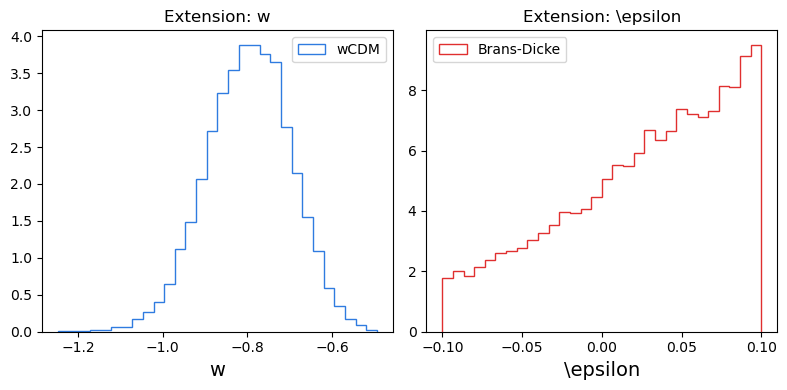

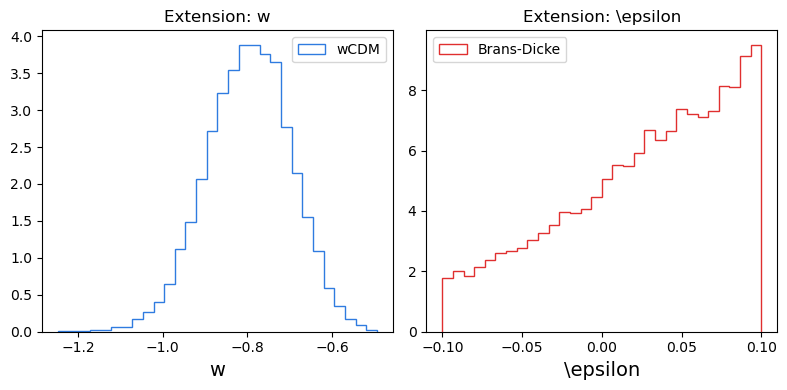

In [4]:
samples_list = [r[0] for r in results_list]
labels_list = [r[1] for r in results_list]

plot_extensions_1d(samples_list, labels_list, names_list)

## 4. Standard Corner Comparison

For completeness, let's also see the shared parameter overlap.

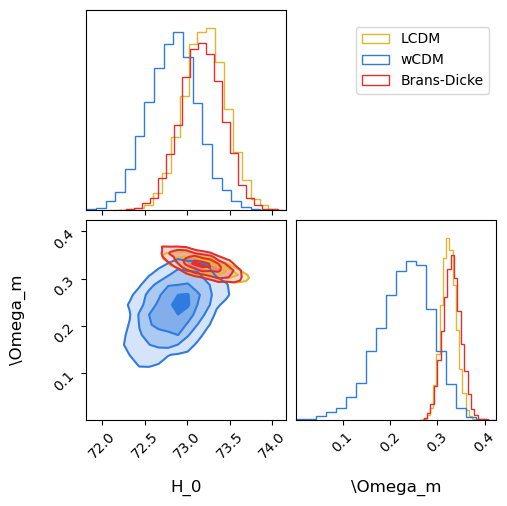

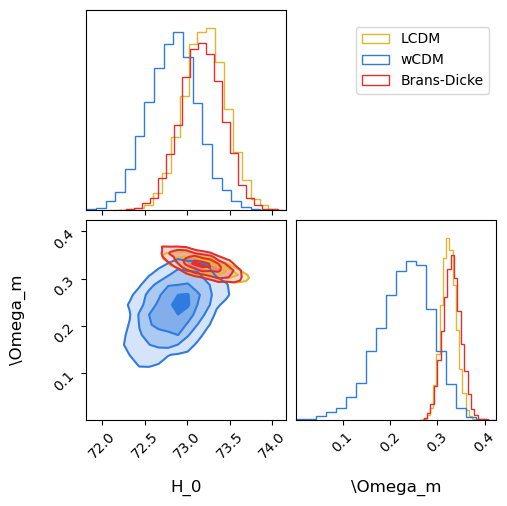

In [5]:
compare_models_corner(samples_list, labels_list, names_list)